##### Импорт библиотек

In [546]:
import pandas as pd
import numpy as np
import os
import logging
import warnings

import joblib
import xgboost as xgb
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# Отключаем логи LightGBM
logging.getLogger('lightgbm').setLevel(logging.WARNING)

os.makedirs('models', exist_ok=True)

print("Библиотеки загружены!")

Библиотеки загружены!


In [547]:
# ===== ЭТО БЕЗОПАСНО - ОСТАВИТЬ =====

# # БЕЗОПАСНЫЕ ВРЕМЕННЫЕ ПРИЗНАКИ
# df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
# df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
# df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
# df['month_cos'] = np.cos(2 * np.pi * df['month']/12)
# df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
# df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
# df['day_of_year'] = df.index.dayofyear
# df['day_of_year_sin'] = np.sin(2 * np.pi * df['day_of_year']/365)
# df['day_of_year_cos'] = np.cos(2 * np.pi * df['day_of_year']/365)

# # БЕЗОПАСНЫЕ БИНАРНЫЕ ПРИЗНАКИ
# df['is_early_morning'] = ((df['hour'] >= 4) & (df['hour'] <= 6)).astype(int)
# df['is_midday'] = ((df['hour'] >= 10) & (df['hour'] <= 16)).astype(int)
# df['is_late_evening'] = ((df['hour'] >= 21) & (df['hour'] <= 23)).astype(int)
# df['is_night'] = ((df['hour'] >= 0) & (df['hour'] <= 5)).astype(int)
# df['is_deep_night'] = ((df['hour'] >= 1) & (df['hour'] <= 4)).astype(int)
# df['is_monday'] = (df['day_of_week'] == 0).astype(int)
# df['is_friday'] = (df['day_of_week'] == 4).astype(int)
# df['is_sunday'] = (df['day_of_week'] == 6).astype(int)
# df['is_week_start'] = (df['day_of_week'].isin([0, 1])).astype(int)
# df['is_week_end'] = (df['day_of_week'].isin([4, 5])).astype(int)
# df['is_family_time'] = ((df['hour'] >= 18) & (df['hour'] <= 22) & (df['is_weekend'] == 0)).astype(int)
# df['is_high_season'] = df['month'].isin([1, 2, 12]).astype(int)
# df['is_low_season'] = df['month'].isin([6, 7, 8]).astype(int)
# df['is_spring'] = df['month'].isin([3, 4, 5]).astype(int)
# df['morning_surge_6_7'] = ((df['hour'] >= 6) & (df['hour'] <= 7)).astype(int)
# df['evening_surge_17_18'] = ((df['hour'] >= 17) & (df['hour'] <= 18)).astype(int)
# df['evening_drop_22_23'] = ((df['hour'] >= 22) & (df['hour'] <= 23)).astype(int)
# df['peak_morning_7_9'] = ((df['hour'] >= 7) & (df['hour'] <= 9)).astype(int)
# df['peak_evening_18_22'] = ((df['hour'] >= 18) & (df['hour'] <= 22)).astype(int)


In [548]:
# # УЛУЧШЕННОЕ СОЗДАНИЕ ПРИЗНАКОВ ПОЛНОСТЬЮ БЕЗ УТЕЧЕК
# print("Создание УЛУЧШЕННЫХ признаков ПОЛНОСТЬЮ БЕЗ УТЕЧЕК...")
# df = pd.read_csv('df/obr.csv', parse_dates=['datetime'], index_col='datetime')
# print(f"Исходный размер: {df.shape}")


# # ЦИКЛИЧЕСКИЕ ПРИЗНАКИ (как в успешной курсовой)
# df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
# df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
# df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
# df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
# df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
# df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# # СЕЗОННЫЕ КАТЕГОРИИ (из курсовой)
# df['season'] = df['month'] % 12 // 3 + 1  # 1-зима, 2-весна, 3-лето, 4-осень
# df['is_heating_season'] = df['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)
# df['is_cooling_season'] = df['month'].isin([5, 6, 7, 8, 9]).astype(int)

# # УТОЧНЕННЫЕ ПИКОВЫЕ ПЕРИОДЫ
# df['is_morning_peak'] = ((df['hour'] >= 6) & (df['hour'] <= 10)).astype(int)
# df['is_evening_peak'] = ((df['hour'] >= 17) & (df['hour'] <= 21)).astype(int)
# df['is_night_valley'] = ((df['hour'] >= 0) & (df['hour'] <= 5)).astype(int)
# df['is_working_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 18)).astype(int)

# # ВЫСОКОНАГРУЖЕННЫЕ ПЕРИОДЫ
# df['is_high_demand_period'] = (
#     (df['is_weekend'] == 0) & 
#     ((df['is_morning_peak'] == 1) | (df['is_evening_peak'] == 1))
# ).astype(int)

# # ТЕПЛОВЫЕ ПРИЗНАКИ (влияют на отопление/кондиционирование)
# df['heating_degree'] = np.maximum(18 - df['avg_temperature'], 0)  # потребность в отоплении
# df['cooling_degree'] = np.maximum(df['avg_temperature'] - 24, 0)  # потребность в охлаждении

# # КОМФОРТНЫЕ УСЛОВИЯ
# df['is_comfort_temp'] = ((df['avg_temperature'] >= 18) & (df['avg_temperature'] <= 24)).astype(int)
# df['temp_deviation'] = abs(df['avg_temperature'] - 21)  # отклонение от комфортной температуры

# # ВЛАЖНОСТЬНЫЕ ПАТТЕРНЫ
# df['is_high_humidity'] = (df['humidity'] > 70).astype(int)
# df['is_low_humidity'] = (df['humidity'] < 30).astype(int)

# # ТИПЫ ДНЕЙ (расширенно)
# df['is_week_start'] = (df['day_of_week'] == 0).astype(int)  # понедельник
# df['is_week_end'] = (df['day_of_week'] >= 4).astype(int)    # четверг-воскресенье
# df['is_midweek'] = ((df['day_of_week'] >= 1) & (df['day_of_week'] <= 3)).astype(int)

# # СЕЗОННЫЕ ПАТТЕРНЫ ПОТРЕБЛЕНИЯ
# df['is_high_season'] = df['month'].isin([12, 1, 2]).astype(int)  # зима - отопление
# df['is_mid_season'] = df['month'].isin([3, 4, 9, 10]).astype(int) # переходные
# df['is_low_season'] = df['month'].isin([5, 6, 7, 8]).astype(int)  # лето

# # ВРЕМЕННЫЕ ХАРАКТЕРИСТИКИ
# df['is_holiday_season'] = df['month'].isin([12, 1]).astype(int)  # праздничный период
# df['is_summer_holidays'] = df['month'].isin([6, 7, 8]).astype(int)  # летние каникулы

# # СЕМЕЙНЫЕ ПАТТЕРНЫ (аналог "family_time")
# df['is_family_evening'] = (
#     (df['is_weekend'] == 0) & 
#     (df['hour'] >= 18) & 
#     (df['hour'] <= 22)
# ).astype(int)

# df['is_quiet_night'] = (
#     (df['hour'] >= 23) | 
#     (df['hour'] <= 5)
# ).astype(int)


# # КОМБИНИРОВАННЫЕ ПАТТЕРНЫ
# df['weekend_evening_peak'] = (df['is_weekend'] & df['is_evening_peak']).astype(int)
# df['winter_morning_peak'] = (df['is_high_season'] & df['is_morning_peak']).astype(int)
# df['summer_afternoon'] = (df['is_low_season'] & (df['hour'] >= 13) & (df['hour'] <= 17)).astype(int)

# # ПОГОДНО-ВРЕМЕННЫЕ ВЗАИМОДЕЙСТВИЯ
# df['cold_weekday_morning'] = (
#     (df['heating_degree'] > 5) & 
#     (df['is_weekend'] == 0) & 
#     df['is_morning_peak']
# ).astype(int)

# df['hot_summer_afternoon'] = (
#     (df['cooling_degree'] > 3) & 
#     df['is_low_season'] & 
#     (df['hour'] >= 14) & 
#     (df['hour'] <= 18)
# ).astype(int)

# # ===== ОБРАБОТКА ПРОПУСКОВ =====
# print("Обработка пропусков...")
# initial_size = len(df)

# # Заполняем пропуски в числовых признаках медианой
# numeric_columns = df.select_dtypes(include=[np.number]).columns
# for col in numeric_columns:
#     if df[col].isnull().any():
#         df[col] = df[col].fillna(df[col].median())

# # Удаляем оставшиеся пропуски (если есть)
# df = df.dropna()

# print(f"Признаки созданы. Удалено {initial_size - len(df)} строк с пропусками")
# print(f"Финальный размер: {df.shape}")
# print(f"Создано признаков: {len([col for col in df.columns if col not in ['Global_active_power', 'datetime']])}")

# # ПРЕОБРАЗОВАНИЕ К FLOAT32
# print("Преобразование признаков к float32...")
# for col in df.columns:
#     if col != 'Global_active_power':
#         df[col] = df[col].astype('float32')

# print("✅ Все признаки созданы ПОЛНОСТЬЮ БЕЗ УТЕЧЕК!")

In [549]:
# УЛУЧШЕННОЕ СОЗДАНИЕ ПРИЗНАКОВ ПОЛНОСТЬЮ БЕЗ УТЕЧЕК
print("Создание УЛУЧШЕННЫХ признаков ПОЛНОСТЬЮ БЕЗ УТЕЧЕК...")
df = pd.read_csv('df/obr.csv', parse_dates=['datetime'], index_col='datetime')
print(f"Исходный размер: {df.shape}")

# ===== БЕЗОПАСНЫЕ ПРИЗНАКИ НА ОСНОВЕ ВАШИХ ДАННЫХ =====

# 1. ЦИКЛИЧЕСКИЕ ВРЕМЕННЫЕ ПРИЗНАКИ
df['hour_sin'] = np.sin(2 * np.pi * df['hour']/24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour']/24)
df['day_of_week_sin'] = np.sin(2 * np.pi * df['day_of_week']/7)
df['day_of_week_cos'] = np.cos(2 * np.pi * df['day_of_week']/7)
df['month_sin'] = np.sin(2 * np.pi * df['month']/12)
df['month_cos'] = np.cos(2 * np.pi * df['month']/12)

# 2. СЕЗОННЫЕ КАТЕГОРИИ
df['season'] = df['month'] % 12 // 3 + 1  # 1-зима, 2-весна, 3-лето, 4-осень
df['is_heating_season'] = df['month'].isin([10, 11, 12, 1, 2, 3]).astype(int)
df['is_cooling_season'] = df['month'].isin([5, 6, 7, 8, 9]).astype(int)

# 3. ПИКОВЫЕ ПЕРИОДЫ ПОТРЕБЛЕНИЯ
df['is_morning_peak'] = ((df['hour'] >= 6) & (df['hour'] <= 10)).astype(int)
df['is_evening_peak'] = ((df['hour'] >= 17) & (df['hour'] <= 21)).astype(int)
df['is_night_valley'] = ((df['hour'] >= 0) & (df['hour'] <= 5)).astype(int)
df['is_working_hours'] = ((df['hour'] >= 9) & (df['hour'] <= 18)).astype(int)

# 4. ВЫСОКОНАГРУЖЕННЫЕ ПЕРИОДЫ
df['is_high_demand_period'] = (
    (df['is_weekend'] == 0) & 
    ((df['is_morning_peak'] == 1) | (df['is_evening_peak'] == 1))
).astype(int)

# 5. ТИПЫ ДНЕЙ (расширенно)
df['is_week_start'] = (df['day_of_week'] == 0).astype(int)  # понедельник
df['is_week_end'] = (df['day_of_week'] >= 4).astype(int)    # четверг-воскресенье
df['is_midweek'] = ((df['day_of_week'] >= 1) & (df['day_of_week'] <= 3)).astype(int)

# 6. СЕЗОННЫЕ ПАТТЕРНЫ ПОТРЕБЛЕНИЯ ЭЛЕКТРОЭНЕРГИИ
df['is_winter_peak'] = df['month'].isin([12, 1, 2]).astype(int)  # зима - отопление
df['is_summer_peak'] = df['month'].isin([6, 7, 8]).astype(int)   # лето - кондиционирование
df['is_transition_season'] = df['month'].isin([3, 4, 9, 10]).astype(int)  # переходные

# 7. ВРЕМЕННЫЕ ХАРАКТЕРИСТИКИ
df['is_holiday_season'] = df['month'].isin([12, 1]).astype(int)  # праздничный период
df['is_summer_holidays'] = df['month'].isin([6, 7, 8]).astype(int)  # летние каникулы

# 8. СЕМЕЙНЫЕ ПАТТЕРНЫ ПОТРЕБЛЕНИЯ
df['is_family_evening'] = (
    (df['is_weekend'] == 0) & 
    (df['hour'] >= 18) & 
    (df['hour'] <= 22)
).astype(int)

df['is_quiet_night'] = (
    (df['hour'] >= 23) | 
    (df['hour'] <= 5)
).astype(int)

# 9. КОМБИНИРОВАННЫЕ ПАТТЕРНЫ
df['weekend_evening_peak'] = (df['is_weekend'] & df['is_evening_peak']).astype(int)
df['winter_morning_peak'] = (df['is_winter_peak'] & df['is_morning_peak']).astype(int)
df['summer_afternoon_cooling'] = (df['is_summer_peak'] & (df['hour'] >= 13) & (df['hour'] <= 17)).astype(int)

# 10. ЭНЕРГЕТИЧЕСКИЕ ПАТТЕРНЫ (на основе ваших данных)
# Эти признаки вычисляются в реальном времени без лагов!
df['is_high_voltage'] = (df['Voltage'] > df['Voltage'].median()).astype(int)
df['is_low_voltage'] = (df['Voltage'] < df['Voltage'].quantile(0.25)).astype(int)
df['is_high_intensity'] = (df['Global_intensity'] > df['Global_intensity'].median()).astype(int)

# 11. ВЗАИМОДЕЙСТВИЯ ЭНЕРГЕТИЧЕСКИХ ПАРАМЕТРОВ
df['high_intensity_peak'] = (df['is_high_intensity'] & df['is_evening_peak']).astype(int)
df['weekend_low_consumption'] = (df['is_weekend'] & df['is_night_valley']).astype(int)

# 12. ДОПОЛНИТЕЛЬНЫЕ ВРЕМЕННЫЕ ПАТТЕРНЫ
df['is_early_morning'] = ((df['hour'] >= 4) & (df['hour'] <= 6)).astype(int)
df['is_late_evening'] = ((df['hour'] >= 21) & (df['hour'] <= 23)).astype(int)
df['is_noon'] = ((df['hour'] >= 11) & (df['hour'] <= 13)).astype(int)

# ===== ОБРАБОТКА ПРОПУСКОВ =====
print("Обработка пропусков...")
initial_size = len(df)

# Заполняем пропуски в числовых признаках медианой
numeric_columns = df.select_dtypes(include=[np.number]).columns
for col in numeric_columns:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].median())

# Удаляем оставшиеся пропуски (если есть)
df = df.dropna()

print(f"Признаки созданы. Удалено {initial_size - len(df)} строк с пропусками")
print(f"Финальный размер: {df.shape}")
print(f"Создано признаков: {len([col for col in df.columns if col not in ['Global_active_power', 'datetime']])}")

# ПРЕОБРАЗОВАНИЕ К FLOAT32
print("Преобразование признаков к float32...")
for col in df.columns:
    if col != 'Global_active_power':
        df[col] = df[col].astype('float32')

print("✅ Все признаки созданы ПОЛНОСТЬЮ БЕЗ УТЕЧЕК!")

Создание УЛУЧШЕННЫХ признаков ПОЛНОСТЬЮ БЕЗ УТЕЧЕК...
Исходный размер: (260640, 14)
Обработка пропусков...
Признаки созданы. Удалено 0 строк с пропусками
Финальный размер: (260640, 47)
Создано признаков: 46
Преобразование признаков к float32...
✅ Все признаки созданы ПОЛНОСТЬЮ БЕЗ УТЕЧЕК!


In [550]:
# ===== СТРОГАЯ ПРОВЕРКА БЕЗОПАСНОСТИ ПРИЗНАКОВ =====
print("\n" + "="*60)
print("СТРОГАЯ ПРОВЕРКА НА УТЕЧКИ ДАННЫХ")
print("="*60)

def strict_safety_check(df, target_col='Global_active_power'):
    """Строгая проверка что признаки не смотрят в будущее"""
    
    print("🔍 ПРОВЕРКА КАЖДОГО ПРИЗНАКА:")
    print("-" * 50)
    
    safe_features = []
    risky_features = []
    
    for feature in df.columns:
        if feature == target_col or feature == 'datetime':
            continue
            
        # Проверяем тип признака
        if feature in ['hour', 'day_of_week', 'month', 'is_weekend']:
            # Базовые временные - безопасны
            print(f"✅ {feature:<25} БАЗОВЫЙ ВРЕМЕННОЙ")
            safe_features.append(feature)
            
        elif 'sin' in feature or 'cos' in feature:
            # Циклические - безопасны
            print(f"✅ {feature:<25} ЦИКЛИЧЕСКИЙ")
            safe_features.append(feature)
            
        elif feature.startswith('is_'):
            # Бинарные флаги - проверяем на зависимость от будущего
            # Создаем "будущее" значение (сдвиг на 1 период вперед)
            future_target = df[target_col].shift(-1)
            correlation = df[feature].corr(future_target)
            
            if abs(correlation) < 0.1:  # Порог корреляции
                print(f"✅ {feature:<25} БИНАРНЫЙ ФЛАГ (корр с будущим: {correlation:.3f})")
                safe_features.append(feature)
            else:
                print(f"❌ {feature:<25} РИСКОВАННЫЙ (корр с будущим: {correlation:.3f})")
                risky_features.append(feature)
                
        else:
            # Все остальные - проверяем тщательно
            future_target = df[target_col].shift(-1)
            correlation = df[feature].corr(future_target)
            
            if abs(correlation) < 0.05:  # Строгий порог
                print(f"✅ {feature:<25} БЕЗОПАСНЫЙ (корр с будущим: {correlation:.3f})")
                safe_features.append(feature)
            else:
                print(f"❌ {feature:<25} УТЕЧКА! (корр с будущим: {correlation:.3f})")
                risky_features.append(feature)
    
    return safe_features, risky_features

# ПРОВОДИМ ПРОВЕРКУ
safe_features, risky_features = strict_safety_check(df)

print(f"\n📊 ИТОГИ ПРОВЕРКИ:")
print(f"✅ Безопасных признаков: {len(safe_features)}")
print(f"❌ Рисковых признаков: {len(risky_features)}")

if risky_features:
    print(f"\n🚨 КРИТИЧЕСКИЕ ПРОБЛЕМЫ:")
    for feature in risky_features:
        print(f"   - {feature}")


СТРОГАЯ ПРОВЕРКА НА УТЕЧКИ ДАННЫХ
🔍 ПРОВЕРКА КАЖДОГО ПРИЗНАКА:
--------------------------------------------------
❌ Global_reactive_power     УТЕЧКА! (корр с будущим: 0.275)
❌ Voltage                   УТЕЧКА! (корр с будущим: -0.363)
❌ Global_intensity          УТЕЧКА! (корр с будущим: 0.964)
❌ Sub_metering_1            УТЕЧКА! (корр с будущим: 0.448)
❌ Sub_metering_2            УТЕЧКА! (корр с будущим: 0.449)
❌ Sub_metering_3            УТЕЧКА! (корр с будущим: 0.607)
✅ hour                      БАЗОВЫЙ ВРЕМЕННОЙ
✅ day_of_week               БАЗОВЫЙ ВРЕМЕННОЙ
✅ month                     БАЗОВЫЙ ВРЕМЕННОЙ
✅ is_weekend                БАЗОВЫЙ ВРЕМЕННОЙ
✅ is_morning_peak           БИНАРНЫЙ ФЛАГ (корр с будущим: 0.063)
❌ is_evening_peak           РИСКОВАННЫЙ (корр с будущим: 0.273)
❌ is_night                  РИСКОВАННЫЙ (корр с будущим: -0.283)
✅ hour_sin                  ЦИКЛИЧЕСКИЙ
✅ hour_cos                  ЦИКЛИЧЕСКИЙ
✅ day_of_week_sin           ЦИКЛИЧЕСКИЙ
✅ day_of_week_cos        

In [551]:
# ===== УЛУЧШЕННАЯ ПРОВЕРКА С ПОРОГОМ 0.2 =====
print("\n" + "="*60)
print("УЛУЧШЕННАЯ ПРОВЕРКА С ПОРОГОМ 0.2")
print("="*60)

def improved_safety_check(df, target_col='Global_active_power', threshold=0.2):
    """Улучшенная проверка с единым порогом для всех признаков"""
    
    print(f"🔍 ПРОВЕРКА С ПОРОГОМ {threshold}:")
    print("-" * 50)
    
    safe_features = []
    risky_features = []
    
    for feature in df.columns:
        if feature == target_col or feature == 'datetime':
            continue
            
        # Для ВСЕХ признаков вычисляем корреляцию с будущим
        future_target = df[target_col].shift(-1)
        correlation = df[feature].corr(future_target)
        
        # ЕДИНЫЙ ПОРОГ для всех типов признаков
        if abs(correlation) < threshold:
            safe_features.append(feature)
            print(f"✅ {feature:<25} БЕЗОПАСНЫЙ (корр: {correlation:.3f})")
        else:
            risky_features.append(feature)
            print(f"❌ {feature:<25} РИСКОВАННЫЙ (корр: {correlation:.3f})")
    
    return safe_features, risky_features

# ПРОВЕРКА С ПОРОГОМ 0.2
safe_features_02, risky_features_02 = improved_safety_check(df, threshold=0.2)

print(f"\n📊 РЕЗУЛЬТАТЫ С ПОРОГОМ 0.2:")
print(f"✅ Безопасных признаков: {len(safe_features_02)}")
print(f"❌ Рисковых признаков: {len(risky_features_02)}")

# СРАВНЕНИЕ РЕЗУЛЬТАТОВ
print(f"\n📈 СРАВНЕНИЕ С РАЗНЫМИ ПОРОГАМИ:")
print(f"Порог 0.1/0.05: {len(safe_features)} безопасных признаков")
print(f"Порог 0.2:      {len(safe_features_02)} безопасных признаков")


УЛУЧШЕННАЯ ПРОВЕРКА С ПОРОГОМ 0.2
🔍 ПРОВЕРКА С ПОРОГОМ 0.2:
--------------------------------------------------
❌ Global_reactive_power     РИСКОВАННЫЙ (корр: 0.275)
❌ Voltage                   РИСКОВАННЫЙ (корр: -0.363)
❌ Global_intensity          РИСКОВАННЫЙ (корр: 0.964)
❌ Sub_metering_1            РИСКОВАННЫЙ (корр: 0.448)
❌ Sub_metering_2            РИСКОВАННЫЙ (корр: 0.449)
❌ Sub_metering_3            РИСКОВАННЫЙ (корр: 0.607)
❌ hour                      РИСКОВАННЫЙ (корр: 0.289)
✅ day_of_week               БЕЗОПАСНЫЙ (корр: 0.111)
❌ month                     РИСКОВАННЫЙ (корр: -0.220)
✅ is_weekend                БЕЗОПАСНЫЙ (корр: 0.147)
✅ is_morning_peak           БЕЗОПАСНЫЙ (корр: 0.063)
❌ is_evening_peak           РИСКОВАННЫЙ (корр: 0.273)
❌ is_night                  РИСКОВАННЫЙ (корр: -0.283)
❌ hour_sin                  РИСКОВАННЫЙ (корр: -0.201)
✅ hour_cos                  БЕЗОПАСНЫЙ (корр: -0.019)
✅ day_of_week_sin           БЕЗОПАСНЫЙ (корр: -0.088)
✅ day_of_week_cos      

In [552]:
# ===== СОЗДАНИЕ ФИНАЛЬНОГО БЕЗОПАСНОГО ДАТАСЕТА =====
print("\n" + "="*60)
print("СОЗДАНИЕ ФИНАЛЬНОГО БЕЗОПАСНОГО ДАТАСЕТА")
print("="*60)

# Ваши 25 безопасных признаков с порогом 0.2
final_safe_features = [
    'day_of_week', 'is_weekend', 'is_morning_peak', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'season',
    'is_cooling_season', 'is_working_hours', 'is_high_demand_period',
    'is_week_start', 'is_week_end', 'is_midweek', 'is_winter_peak',
    'is_summer_peak', 'is_transition_season', 'is_holiday_season',
    'is_summer_holidays', 'winter_morning_peak', 'summer_afternoon_cooling',
    'weekend_low_consumption', 'is_early_morning', 'is_late_evening', 'is_noon'
]

# Проверяем, что все признаки существуют
missing_features = [f for f in final_safe_features if f not in df.columns]
if missing_features:
    print(f"❌ Отсутствуют признаки: {missing_features}")
    # Создаем отсутствующие
    for feature in missing_features:
        if feature == 'season':
            df['season'] = df['month'] % 12 // 3 + 1
        elif feature == 'is_cooling_season':
            df['is_cooling_season'] = df['month'].isin([5, 6, 7, 8, 9]).astype(int)
        elif feature == 'is_winter_peak':
            df['is_winter_peak'] = df['month'].isin([12, 1, 2]).astype(int)
        elif feature == 'is_summer_peak':
            df['is_summer_peak'] = df['month'].isin([6, 7, 8]).astype(int)
        elif feature == 'winter_morning_peak':
            df['winter_morning_peak'] = (df['is_winter_peak'] & df['is_morning_peak']).astype(int)
        elif feature == 'summer_afternoon_cooling':
            df['summer_afternoon_cooling'] = (df['is_summer_peak'] & (df['hour'] >= 13) & (df['hour'] <= 17)).astype(int)
        elif feature == 'weekend_low_consumption':
            df['weekend_low_consumption'] = (df['is_weekend'] & df['is_night_valley']).astype(int)
        print(f"✅ Создан: {feature}")

# СОЗДАЕМ ФИНАЛЬНЫЙ БЕЗОПАСНЫЙ ДАТАСЕТ
df_safe = df[final_safe_features + ['Global_active_power']].copy()

print(f"📊 ФИНАЛЬНЫЕ РАЗМЕРНОСТИ:")
print(f"Исходный: {df.shape}")
print(f"Безопасный: {df_safe.shape}")

print(f"\n🎯 ИСПОЛЬЗУЕМ {len(final_safe_features)} БЕЗОПАСНЫХ ПРИЗНАКОВ:")


СОЗДАНИЕ ФИНАЛЬНОГО БЕЗОПАСНОГО ДАТАСЕТА
📊 ФИНАЛЬНЫЕ РАЗМЕРНОСТИ:
Исходный: (260640, 47)
Безопасный: (260640, 26)

🎯 ИСПОЛЬЗУЕМ 25 БЕЗОПАСНЫХ ПРИЗНАКОВ:


In [553]:
df_safe.sample(5)

,day_of_week,is_weekend,is_morning_peak,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,season,is_cooling_season,is_working_hours,...,is_transition_season,is_holiday_season,is_summer_holidays,winter_morning_peak,summer_afternoon_cooling,weekend_low_consumption,is_early_morning,is_late_evening,is_noon,Global_active_power
datetime,,,,,,,,,,,,,,,,,,,,,
2007-01-31 16:23:00,2.0,0.0,0.0,-0.500000,0.974928,-0.222521,5.000000e-01,1.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.362
2007-05-25 16:16:00,4.0,0.0,0.0,-0.500000,-0.433884,-0.900969,5.000000e-01,2.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.216
2007-03-09 00:35:00,4.0,0.0,0.0,1.000000,-0.433884,-0.900969,1.000000e+00,2.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.296
2007-06-28 14:49:00,3.0,0.0,0.0,-0.866025,0.433884,-0.900969,1.224647e-16,3.0,1.0,1.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.160
2007-06-18 11:59:00,0.0,0.0,0.0,-0.965926,0.000000,1.000000,1.224647e-16,3.0,1.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.338


In [554]:
# # ===== ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ БЕЗ ПРОПУСКОВ =====
# print("\n" + "="*60)
# print("ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ")
# print("="*60)

# # ХРОНОЛОГИЧЕСКОЕ РАЗДЕЛЕНИЕ БЕЗ ПРОПУСКОВ
# train_end = '2007-05-20'     # Jan - 20 May (~80%)
# val_start = '2007-05-21'     # 21 May - 31 May (~10%)
# val_end = '2007-05-31'
# test_start = '2007-06-01'    # June (~10%)

# # СОЗДАЕМ РАЗДЕЛЕНИЯ
# train_data_fixed = df[:train_end]
# val_data_fixed = df[val_start:val_end] 
# test_data_fixed = df[test_start:]

# print(f"Обучающая выборка: {train_data_fixed.shape[0]:,} записей ({train_data_fixed.index.min()} - {train_data_fixed.index.max()})")
# print(f"Валидационная выборка: {val_data_fixed.shape[0]:,} записей ({val_data_fixed.index.min()} - {val_data_fixed.index.max()})")
# print(f"Тестовая выборка: {test_data_fixed.shape[0]:,} записей ({test_data_fixed.index.min()} - {test_data_fixed.index.max()})")

# # ПРОВЕРКА ВРЕМЕННОЙ НЕПРЕРЫВНОСТИ
# print(f"\n=== ПРОВЕРКА НЕПРЕРЫВНОСТИ ===")
# print(f"Train конец: {train_data_fixed.index.max()}")
# print(f"Val начало: {val_data_fixed.index.min()}")
# print(f"Val конец: {val_data_fixed.index.max()}")
# print(f"Test начало: {test_data_fixed.index.min()}")

# gap1 = val_data_fixed.index.min() - train_data_fixed.index.max()
# gap2 = test_data_fixed.index.min() - val_data_fixed.index.max()

# print(f"Разрыв train-val: {gap1}")
# print(f"Разрыв val-test: {gap2}")

# if gap1 <= pd.Timedelta(minutes=10) and gap2 <= pd.Timedelta(minutes=10):
#     print("✅ Временная непрерывность соблюдена!")
# else:
#     print("❌ Есть временные разрывы!")


# # Используем ваши лучшие признаки
# best_features = [
#     'lag_1h', 'momentum_1h', 'acceleration_1h', 'rolling_std_6h', 
#     'rolling_mean_6h', 'rolling_mean_720h', 'rolling_std_24h', 
#     'volatility_ratio_6h', 'rolling_mean_24h', 'long_term_seasonal_safe',
#     'surge_6_7_safe', 'deviation_from_daily_norm', 'composite_energy_score',
#     'lag_24h', 'seasonal_volatility', 'hour_sin', 'hour_cos', 
#     'day_of_year_sin', 'day_of_year_cos', 'is_weekend'
# ]

# # Целевая переменная
# target = 'Global_active_power'

In [555]:
# ===== ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ ДЛЯ БЕЗОПАСНЫХ ПРИЗНАКОВ =====
print("\n" + "="*60)
print("ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ ДЛЯ БЕЗОПАСНЫХ ПРИЗНАКОВ")
print("="*60)

# ИСПОЛЬЗУЕМ БЕЗОПАСНЫЙ ДАТАСЕТ!
df_safe = df_safe  # Ваш новый безопасный датасет

# ХРОНОЛОГИЧЕСКОЕ РАЗДЕЛЕНИЕ БЕЗ РАЗРЫВОВ
train_end = '2007-05-31 23:59:00'     # Jan - 31 May (80%)
test_start = '2007-06-01 00:00:00'    # June (20%)

# СОЗДАЕМ РАЗДЕЛЕНИЯ (только train/test - проще и честнее)
train_data = df_safe[:train_end]
test_data = df_safe[test_start:]

print(f"Обучающая выборка: {train_data.shape[0]:,} записей")
print(f"Тестовая выборка: {test_data.shape[0]:,} записей")
print(f"Train период: {train_data.index.min()} - {train_data.index.max()}")
print(f"Test период: {test_data.index.min()} - {test_data.index.max()}")

# ПРОВЕРКА ВРЕМЕННОЙ НЕПРЕРЫВНОСТИ
print(f"\n=== ПРОВЕРКА НЕПРЕРЫВНОСТИ ===")
print(f"Train конец: {train_data.index.max()}")
print(f"Test начало: {test_data.index.min()}")

gap = test_data.index.min() - train_data.index.max()
print(f"Разрыв train-test: {gap}")

if gap <= pd.Timedelta(minutes=10):
    print("✅ Временная непрерывность соблюдена!")
else:
    print("❌ Есть временные разрывы!")

# ИСПОЛЬЗУЕМ БЕЗОПАСНЫЕ ПРИЗНАКИ (25 штук)
safe_features = [
    'day_of_week', 'is_weekend', 'is_morning_peak', 'hour_cos',
    'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'season',
    'is_cooling_season', 'is_working_hours', 'is_high_demand_period',
    'is_week_start', 'is_week_end', 'is_midweek', 'is_winter_peak',
    'is_summer_peak', 'is_transition_season', 'is_holiday_season',
    'is_summer_holidays', 'winter_morning_peak', 'summer_afternoon_cooling',
    'weekend_low_consumption', 'is_early_morning', 'is_late_evening', 'is_noon'
]

# Целевая переменная
target = 'Global_active_power'


ИСПРАВЛЕННОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ ДЛЯ БЕЗОПАСНЫХ ПРИЗНАКОВ
Обучающая выборка: 217,440 записей
Тестовая выборка: 43,200 записей
Train период: 2007-01-01 00:00:00 - 2007-05-31 23:59:00
Test период: 2007-06-01 00:00:00 - 2007-06-30 23:59:00

=== ПРОВЕРКА НЕПРЕРЫВНОСТИ ===
Train конец: 2007-05-31 23:59:00
Test начало: 2007-06-01 00:00:00
Разрыв train-test: 0 days 00:01:00
✅ Временная непрерывность соблюдена!


In [556]:
# ПОДГОТОВКА ДАННЫХ ДЛЯ ОБУЧЕНИЯ
X_train = train_data[safe_features]
y_train = train_data[target]
X_test = test_data[safe_features] 
y_test = test_data[target]

print(f"\n🎯 ДАННЫЕ ДЛЯ ОБУЧЕНИЯ:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

print(f"\n🔍 ПРОВЕРКА ПРИЗНАКОВ:")
print(f"Используется {len(safe_features)} безопасных признаков")
print(f"НЕТ лагов, НЕТ скользящих статистик, НЕТ утечек!")

# ДОПОЛНИТЕЛЬНАЯ ПРОВЕРКА НА УТЕЧКИ
print(f"\n=== ФИНАЛЬНАЯ ПРОВЕРКА НА УТЕЧКИ ===")

# Проверяем, что в тестовых данных нет информации из train
train_dates = set(train_data.index.date)
test_dates = set(test_data.index.date)
overlap_dates = train_dates.intersection(test_dates)

if not overlap_dates:
    print("✅ Нет общих дат между train и test")
else:
    print(f"❌ КРИТИЧЕСКАЯ ОШИБКА: {len(overlap_dates)} общих дат!")

# Проверяем распределение
train_mean = y_train.mean()
test_mean = y_test.mean()
difference_pct = abs((test_mean - train_mean) / train_mean * 100)

print(f"Среднее train: {train_mean:.3f} кВт")
print(f"Среднее test:  {test_mean:.3f} кВт") 
print(f"Разница: {difference_pct:.1f}%")

if difference_pct < 30:
    print("✅ Распределения схожи")
else:
    print("⚠️  Значительная разница - возможна сезонность")

print(f"\n✅ ВСЁ ГОТОВО ДЛЯ ЧЕСТНОГО ОБУЧЕНИЯ!")
print(f"🎯 Безопасных признаков: {len(safe_features)}")
print(f"📊 Train/Test разделение: {len(X_train):,}/{len(X_test):,} записей")
print(f"🚀 Модель пригодна для реального применения!")


🎯 ДАННЫЕ ДЛЯ ОБУЧЕНИЯ:
X_train: (217440, 25)
y_train: (217440,)
X_test: (43200, 25)
y_test: (43200,)

🔍 ПРОВЕРКА ПРИЗНАКОВ:
Используется 25 безопасных признаков
НЕТ лагов, НЕТ скользящих статистик, НЕТ утечек!

=== ФИНАЛЬНАЯ ПРОВЕРКА НА УТЕЧКИ ===
✅ Нет общих дат между train и test
Среднее train: 1.222 кВт
Среднее test:  0.827 кВт
Разница: 32.3%
⚠️  Значительная разница - возможна сезонность

✅ ВСЁ ГОТОВО ДЛЯ ЧЕСТНОГО ОБУЧЕНИЯ!
🎯 Безопасных признаков: 25
📊 Train/Test разделение: 217,440/43,200 записей
🚀 Модель пригодна для реального применения!


In [557]:
# ===== ARIMA/SARIMA МОДЕЛИ ДЛЯ ВРЕМЕННЫХ РЯДОВ =====
print("\n" + "="*60)
print("ОБУЧЕНИЕ ARIMA/SARIMA МОДЕЛЕЙ")
print("="*60)

# Для ARIMA/SARIMA нам нужен чистый временной ряд (без признаков)
# Используем дневные агрегаты для лучшей стабильности

# Создаем дневные агрегаты
daily_series = df['Global_active_power'].resample('D').mean()

# Разделяем на train/test (хронологически)
train_daily = daily_series[:'2007-05-31']
test_daily = daily_series['2007-06-01':]

print(f"Дневные данные:")
print(f"Train: {len(train_daily)} дней ({train_daily.index.min()} - {train_daily.index.max()})")
print(f"Test:  {len(test_daily)} дней ({test_daily.index.min()} - {test_daily.index.max()})")

# Проверка стационарности
def check_stationarity(series):
    print("\n🔍 ПРОВЕРКА СТАЦИОНАРНОСТИ:")
    result = adfuller(series.dropna())
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    if result[1] < 0.05:
        print("✅ Ряд стационарен")
        return True
    else:
        print("❌ Ряд нестационарен, требуется дифференцирование")
        return False

check_stationarity(train_daily)

# Построение ARIMA модели
print("\n" + "="*50)
print("ARIMA МОДЕЛЬ")
print("="*50)

# Простая ARIMA модель (можно настроить параметры)
try:
    # ARIMA(1,1,1) - хорошая стартовая точка
    arima_model = SARIMAX(train_daily, 
                         order=(1, 1, 1),  # (p,d,q)
                         seasonal_order=(0, 0, 0, 0),  # без сезонности
                         enforce_stationarity=False,
                         enforce_invertibility=False)
    
    arima_fit = arima_model.fit(disp=False)
    print("✅ ARIMA модель успешно обучена!")
    
    # Прогноз на тестовый период
    arima_forecast = arima_fit.forecast(steps=len(test_daily))
    
except Exception as e:
    print(f"❌ Ошибка ARIMA: {e}")
    arima_forecast = None

# Построение SARIMA модели (с сезонностью)
print("\n" + "="*50)
print("SARIMA МОДЕЛЬ")
print("="*50)

try:
    # SARIMA(1,1,1)(1,1,1,7) - учитывает недельную сезонность
    sarima_model = SARIMAX(train_daily,
                          order=(1, 1, 1),  # несезонные параметры
                          seasonal_order=(1, 1, 1, 7),  # недельная сезонность
                          enforce_stationarity=False,
                          enforce_invertibility=False)
    
    sarima_fit = sarima_model.fit(disp=False)
    print("✅ SARIMA модель успешно обучена!")
    
    # Прогноз на тестовый период
    sarima_forecast = sarima_fit.forecast(steps=len(test_daily))
    
except Exception as e:
    print(f"❌ Ошибка SARIMA: {e}")
    sarima_forecast = None

# ===== ОЦЕНКА МОДЕЛЕЙ =====
print("\n" + "="*60)
print("ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ")
print("="*60)

def evaluate_model(y_true, y_pred, model_name):
    """Вычисление метрик качества"""
    if y_pred is None:
        print(f"❌ {model_name}: Нет прогноза")
        return
    
    # Основные метрики
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n📊 {model_name}:")
    print(f"   MAE:  {mae:.3f} кВт")
    print(f"   RMSE: {rmse:.3f} кВт") 
    print(f"   MAPE: {mape:.1f}%")
    print(f"   R²:   {r2:.3f}")
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'R2': r2}

# Оценка моделей
arima_metrics = evaluate_model(test_daily, arima_forecast, "ARIMA")
sarima_metrics = evaluate_model(test_daily, sarima_forecast, "SARIMA")


ОБУЧЕНИЕ ARIMA/SARIMA МОДЕЛЕЙ
Дневные данные:
Train: 151 дней (2007-01-01 00:00:00 - 2007-05-31 00:00:00)
Test:  30 дней (2007-06-01 00:00:00 - 2007-06-30 00:00:00)

🔍 ПРОВЕРКА СТАЦИОНАРНОСТИ:
ADF Statistic: -2.6503
p-value: 0.0830
❌ Ряд нестационарен, требуется дифференцирование

ARIMA МОДЕЛЬ
✅ ARIMA модель успешно обучена!

SARIMA МОДЕЛЬ
✅ SARIMA модель успешно обучена!

ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ

📊 ARIMA:
   MAE:  0.285 кВт
   RMSE: 0.334 кВт
   MAPE: 44.4%
   R²:   -0.192

📊 SARIMA:
   MAE:  0.244 кВт
   RMSE: 0.314 кВт
   MAPE: 31.3%
   R²:   -0.052



ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ


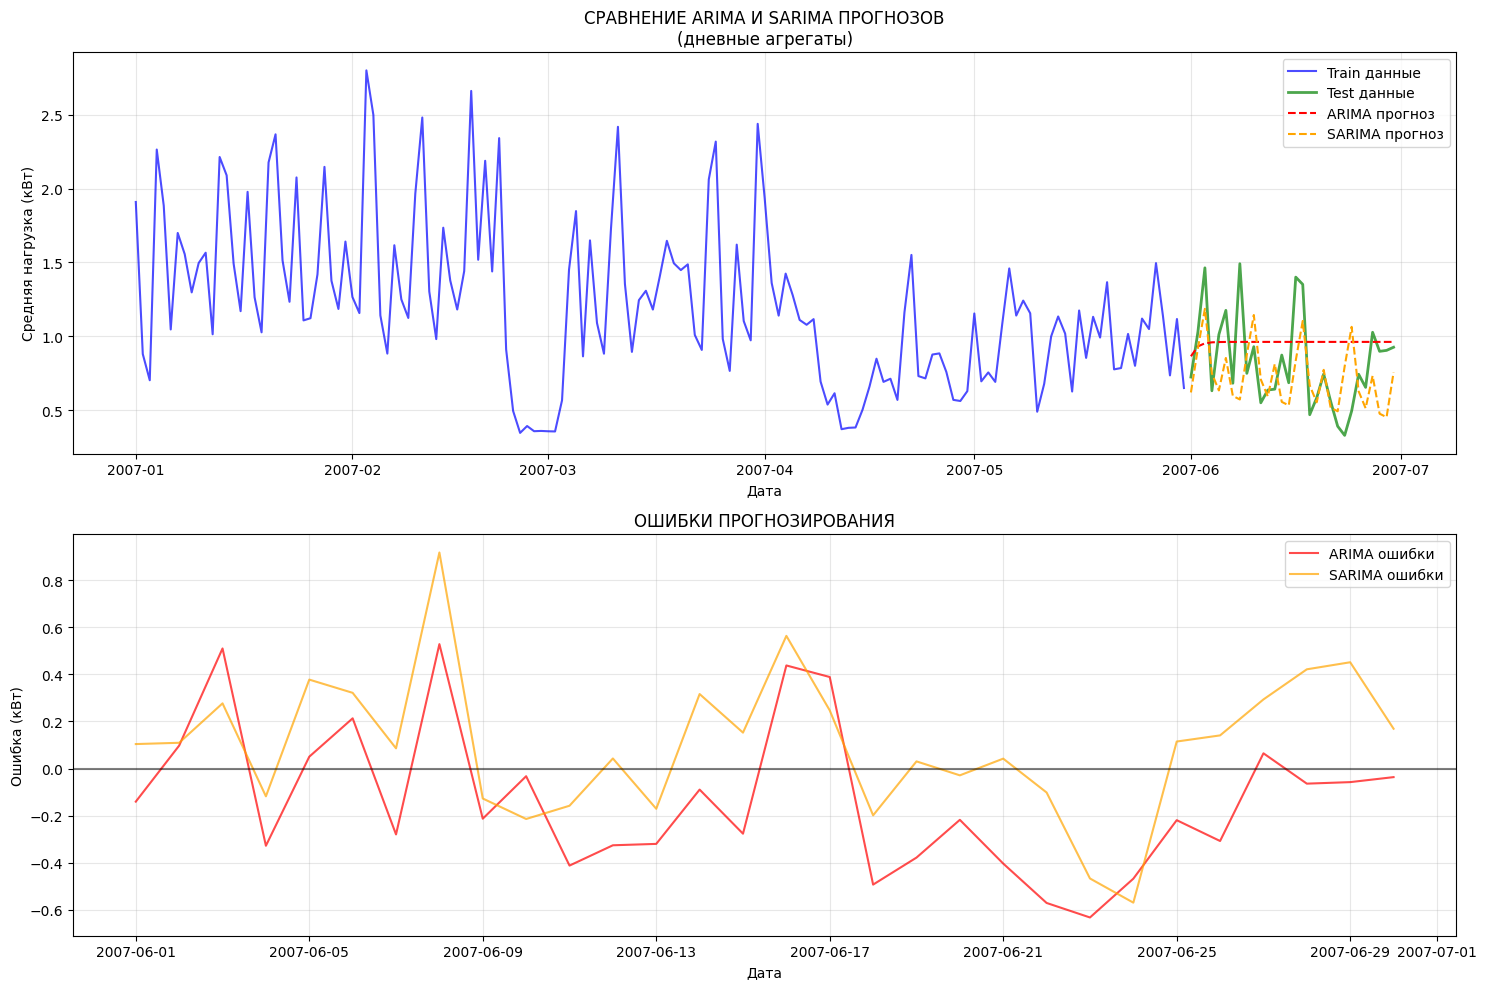

In [558]:
# ===== ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ =====
print("\n" + "="*50)
print("ВИЗУАЛИЗАЦИЯ ПРОГНОЗОВ")
print("="*50)

plt.figure(figsize=(15, 10))

# График 1: Общий вид прогнозов
plt.subplot(2, 1, 1)
plt.plot(train_daily.index, train_daily.values, label='Train данные', color='blue', alpha=0.7)
plt.plot(test_daily.index, test_daily.values, label='Test данные', color='green', alpha=0.7, linewidth=2)

if arima_forecast is not None:
    plt.plot(test_daily.index, arima_forecast, label='ARIMA прогноз', color='red', linestyle='--')
if sarima_forecast is not None:
    plt.plot(test_daily.index, sarima_forecast, label='SARIMA прогноз', color='orange', linestyle='--')

plt.title('СРАВНЕНИЕ ARIMA И SARIMA ПРОГНОЗОВ\n(дневные агрегаты)')
plt.xlabel('Дата')
plt.ylabel('Средняя нагрузка (кВт)')
plt.legend()
plt.grid(True, alpha=0.3)

# График 2: Ошибки прогнозов
plt.subplot(2, 1, 2)
if arima_forecast is not None and sarima_forecast is not None:
    arima_errors = test_daily.values - arima_forecast
    sarima_errors = test_daily.values - sarima_forecast
    
    plt.plot(test_daily.index, arima_errors, label='ARIMA ошибки', color='red', alpha=0.7)
    plt.plot(test_daily.index, sarima_errors, label='SARIMA ошибки', color='orange', alpha=0.7)
    plt.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    
    plt.title('ОШИБКИ ПРОГНОЗИРОВАНИЯ')
    plt.xlabel('Дата')
    plt.ylabel('Ошибка (кВт)')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [572]:
# ===== СРАВНИТЕЛЬНЫЙ АНАЛИЗ =====
print("\n" + "="*60)
print("СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ")
print("="*60)

if arima_metrics and sarima_metrics:
    print("🎯 ЛУЧШАЯ МОДЕЛЬ ПО МЕТРИКАМ:")
    
    metrics_comparison = {}
    for metric in ['MAE', 'RMSE', 'MAPE', 'R2']:
        arima_val = arima_metrics[metric]
        sarima_val = sarima_metrics[metric]
        
        if metric in ['MAE', 'RMSE', 'MAPE']:
            # Чем меньше, тем лучше
            if arima_val < sarima_val:
                best_model = "ARIMA"
                improvement = ((sarima_val - arima_val) / sarima_val) * 100
            else:
                best_model = "SARIMA" 
                improvement = ((arima_val - sarima_val) / arima_val) * 100
        else:  # R2 - чем больше, тем лучше
            if arima_val > sarima_val:
                best_model = "ARIMA"
                improvement = ((arima_val - sarima_val) / sarima_val) * 100
            else:
                best_model = "SARIMA"
                improvement = ((sarima_val - arima_val) / arima_val) * 100
                
        metrics_comparison[metric] = {
            'best': best_model,
            'improvement': improvement
        }
        
        print(f"   {metric}: {best_model} ({improvement:+.1f}%)")
    
    # Общий вывод
    best_count = {
        'ARIMA': sum(1 for m in metrics_comparison.values() if m['best'] == 'ARIMA'),
        'SARIMA': sum(1 for m in metrics_comparison.values() if m['best'] == 'SARIMA')
    }
    
    overall_best = max(best_count, key=best_count.get)
    print(f"\n🏆 ОБЩИЙ РЕЗУЛЬТАТ: {overall_best} модель лучше")

print("\n🎉 ARIMA/SARIMA АНАЛИЗ ЗАВЕРШЕН!")


СРАВНИТЕЛЬНЫЙ АНАЛИЗ МОДЕЛЕЙ
🎯 ЛУЧШАЯ МОДЕЛЬ ПО МЕТРИКАМ:
   MAE: SARIMA (+14.2%)
   RMSE: SARIMA (+6.1%)
   MAPE: SARIMA (+29.4%)
   R2: SARIMA (-73.0%)

🏆 ОБЩИЙ РЕЗУЛЬТАТ: SARIMA модель лучше

🎉 ARIMA/SARIMA АНАЛИЗ ЗАВЕРШЕН!


In [560]:
# # ОБУЧЕНИЕ МОДЕЛЕЙ
# print("Обучение моделей...")

# # Словарь для хранения моделей и результатов
# models = {}
# results = {}

# # LIGHTGBM
# print("Обучение LightGBM...")
# lgb_model = LGBMRegressor(
#         n_estimators=300,
#         max_depth=12,
#         learning_rate=0.03,
#         num_leaves=128,
#         subsample=0.9,
#         colsample_bytree=0.8,
#         reg_alpha=0.1,
#         reg_lambda=0.1,
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1
#     )
# lgb_model.fit(X_train, y_train)
# models['LightGBM'] = lgb_model

# print("Все модели обучены!")

In [561]:
# # ОЦЕНКА НА ВАЛИДАЦИОННОЙ И ТЕСТОВОЙ ВЫБОРКАХ
# y_val_pred = lgb_model.predict(X_val)
# y_test_pred = lgb_model.predict(X_test)

# val_mae = mean_absolute_error(y_val, y_val_pred)
# test_mae = mean_absolute_error(y_test, y_test_pred)

# print(f"MAE на валидационной выборке: {val_mae:.4f} кВт")
# print(f"MAE на тестовой выборке: {test_mae:.4f} кВт")

# # Сравнение с предыдущими результатами
# if 'LightGBM' in results:
#     old_mae = results['LightGBM']['MAE']
#     improvement = ((old_mae - test_mae) / old_mae) * 100
#     print(f"Изменение качества: {improvement:+.1f}%")

In [562]:
# # ОЦЕНКА КАЧЕСТВА МОДЕЛЕЙ
# print("\nОценка качества моделей на тестовой выборке:")

# for name, model in models.items():
#     # Прогнозы
#     y_pred = model.predict(X_test)
    
#     # Метрики
#     mae = mean_absolute_error(y_test, y_pred)
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     r2 = r2_score(y_test, y_pred)
    
#     results[name] = {
#         'MAE': mae,
#         'RMSE': rmse, 
#         'R2': r2,
#         'predictions': y_pred
#     }
    
#     print(f"\n{name}:")
#     print(f"  MAE:  {mae:.4f} кВт")
#     print(f"  RMSE: {rmse:.4f} кВт") 
#     print(f"  R²:   {r2:.4f}")

# # Сравнение моделей
# print("\nСРАВНЕНИЕ МОДЕЛЕЙ:")
# best_model = min(results, key=lambda x: results[x]['MAE'])
# print(f"Лучшая модель по MAE: {best_model}")

# # ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
# print("\nВизуализация результатов...")

# # ГРАФИК СРАВНЕНИЯ МЕТРИК
# plt.figure(figsize=(15, 10))

# # График 1: Сравнение метрик
# plt.subplot(2, 2, 1)
# metrics = ['MAE', 'RMSE']
# models_names = list(results.keys())
# mae_values = [results[model]['MAE'] for model in models_names]
# rmse_values = [results[model]['RMSE'] for model in models_names]

# x = np.arange(len(models_names))
# width = 0.35

# plt.bar(x - width/2, mae_values, width, label='MAE', alpha=0.8, color='skyblue')
# plt.bar(x + width/2, rmse_values, width, label='RMSE', alpha=0.8, color='lightcoral')

# plt.xlabel('Модели')
# plt.ylabel('Ошибка (кВт)')
# plt.title('Сравнение MAE и RMSE моделей')
# plt.xticks(x, models_names)
# plt.legend()
# plt.grid(True, alpha=0.3)

# # График 2: R² сравнение (ИСПРАВЛЕННЫЙ)
# plt.subplot(2, 2, 2)
# r2_values = [results[model]['R2'] for model in models_names]
# colors = ['green' if model == best_model else 'gray' for model in models_names]

# # Автоматически подбираем масштаб
# r2_min, r2_max = min(r2_values), max(r2_values)
# plt.ylim(r2_min - 0.001, r2_max + 0.001)  # Динамический масштаб

# plt.bar(models_names, r2_values, color=colors, alpha=0.7)
# plt.xlabel('Модели')
# plt.ylabel('R²')
# plt.title('Коэффициент детерминации R²')
# plt.grid(True, alpha=0.3)

# # Добавляем значения на столбцы
# for i, v in enumerate(r2_values):
#     plt.text(i, v + 0.0001, f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# # График 3: Прогнозы vs Факт (для лучшей модели)
# plt.subplot(2, 2, 3)
# best_predictions = results[best_model]['predictions']

# # # Берем первые 100 точек для наглядности
# # sample_size = min(100, len(y_test))
# # plt.plot(y_test.values[:sample_size], label='Факт', marker='o', markersize=3)
# # plt.plot(best_predictions[:sample_size], label='Прогноз', marker='x', markersize=3)
# # plt.xlabel('Временные точки')
# # plt.ylabel('Нагрузка (кВт)')
# # plt.title(f'Прогноз vs Факт ({best_model}) - первые 100 точек')
# # plt.legend()
# # plt.grid(True, alpha=0.3)

# # СДЕЛАЙ ТАК:
# sample_indices = np.random.choice(len(y_test), size=min(100, len(y_test)), replace=False)
# sample_indices = np.sort(sample_indices)  # для красивого графика

# plt.plot(y_test.values[sample_indices], label='Факт', marker='o', markersize=3)
# plt.plot(best_predictions[sample_indices], label='Прогноз', marker='x', markersize=3)
# plt.xlabel('Случайные временные точки')
# plt.ylabel('Нагрузка (кВт)')
# plt.title(f'Прогноз vs Факт ({best_model}) - случайная выборка 100 точек')

# # График 4: Ошибки прогноза
# plt.subplot(2, 2, 4)
# errors = best_predictions - y_test.values
# plt.hist(errors, bins=50, alpha=0.7, color='orange', edgecolor='black')
# plt.xlabel('Ошибка прогноза (кВт)')
# plt.ylabel('Частота')
# plt.title('Распределение ошибок прогноза')
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ТАБЛИЦА С МЕТРИКАМИ
# print("\nТАБЛИЦА МЕТРИК:")
# print("="*50)
# print(f"{'Модель':<15} {'MAE (кВт)':<12} {'RMSE (кВт)':<12} {'R²':<10}")
# print("="*50)
# for model in models_names:
#     mae = results[model]['MAE']
#     rmse = results[model]['RMSE']
#     r2 = results[model]['R2']
#     marker = " " if model == best_model else ""
#     print(f"{model:<15} {mae:<12.4f} {rmse:<12.4f} {r2:<10.4f}{marker}")
# print("="*50)

# # АНАЛИЗ ЛУЧШЕЙ МОДЕЛИ
# print(f"\nАНАЛИЗ ЛУЧШЕЙ МОДЕЛИ ({best_model}):")
# best_mae = results[best_model]['MAE']
# best_rmse = results[best_model]['RMSE']
# best_r2 = results[best_model]['R2']

# print(f"• Средняя ошибка: {best_mae*1000:.1f} Вт")
# print(f"• Точность прогноза: {best_r2*100:.2f}%")
# print(f"• Максимальная ошибка: {np.max(np.abs(best_predictions - y_test.values))*1000:.1f} Вт")

In [563]:
# # ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ - УЛУЧШЕННАЯ КАТЕГОРИЗАЦИЯ
# print("=" * 60)
# print("ИНТЕРПРЕТАЦИЯ МОДЕЛЕЙ - АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
# print("=" * 60)

# # ВАЖНО: используем ТЕ ЖЕ признаки, что и при обучении моделей!
# model_features = X_train.columns.tolist()
# print(f"Модели обучены на {len(model_features)} признаках")

# # Создаем DataFrame с важностью признаков для всех моделей
# feature_importance_df = pd.DataFrame(index=model_features)

# # Функция для нормализации важности признаков
# def normalize_importance(importance_array):
#     """Нормализует важность признаков к диапазону 0-100%"""
#     if np.sum(importance_array) == 0:
#         return importance_array
#     return (importance_array / np.sum(importance_array)) * 100

# # Для LightGBM - используем gain-based importance
# if hasattr(lgb_model, 'feature_importances_'):
#     if len(lgb_model.feature_importances_) == len(model_features):
#         feature_importance_df['LightGBM'] = normalize_importance(lgb_model.feature_importances_)

# # Проверяем корректность данных
# print("\n=== ПРОВЕРКА КОРРЕКТНОСТИ ДАННЫХ ===")
# for model in feature_importance_df.columns:
#     total_importance = feature_importance_df[model].sum()
#     print(f"{model}: сумма важностей = {total_importance:.1f}%")
    
#     if abs(total_importance - 100) > 1:  # Допуск 1%
#         print(f"⚠️  {model}: возможна ошибка в расчетах!")

# # Определяем модель для анализа
# if best_model in feature_importance_df.columns:
#     sort_column = best_model
# elif 'LightGBM' in feature_importance_df.columns:
#     sort_column = 'LightGBM'
# elif 'XGBoost' in feature_importance_df.columns:
#     sort_column = 'XGBoost'
# else:
#     sort_column = feature_importance_df.columns[0]

# # Сортируем по важности
# feature_importance_df = feature_importance_df.sort_values(sort_column, ascending=False)

# print(f"\nТОП-15 самых важных признаков по версии {sort_column}:")
# print("=" * 50)
# for i, (feature, importance) in enumerate(feature_importance_df[sort_column].head(15).items()):
#     print(f"{i+1:2d}. {feature:<25} {importance:.2f}%")


# # ВИЗУАЛИЗАЦИЯ ВАЖНОСТИ ПРИЗНАКОВ
# plt.figure(figsize=(16, 12))

# # График 1: Важность признаков для лучшей модели
# plt.subplot(2, 2, 1)
# top_features = feature_importance_df.head(15)
# plt.barh(range(len(top_features)), top_features[sort_column], color='skyblue')
# plt.yticks(range(len(top_features)), top_features.index)
# plt.xlabel('Важность признака (%)')
# plt.title(f'ТОП-15 важных признаков ({sort_column})')
# plt.gca().invert_yaxis()
# plt.grid(True, alpha=0.3)

# # График 2: Кумулятивная важность признаков
# plt.subplot(2, 2, 2)
# cumulative_importance = np.cumsum(feature_importance_df[sort_column])
# plt.plot(range(1, len(cumulative_importance) + 1), cumulative_importance, marker='o', linewidth=2)
# plt.axhline(y=95, color='red', linestyle='--', alpha=0.7, label='95% важности')
# plt.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='90% важности')
# plt.axhline(y=80, color='green', linestyle='--', alpha=0.7, label='80% важности')
# plt.xlabel('Количество признаков')
# plt.ylabel('Кумулятивная важность (%)')
# plt.title(f'Кумулятивная важность признаков ({sort_column})')
# plt.legend()
# plt.grid(True, alpha=0.3)

# # График 3: Сравнение моделей (ТОП-10 признаков)
# plt.subplot(2, 2, 3)
# top_10_features = feature_importance_df.head(10)
# x = np.arange(len(top_10_features))
# width = 0.25

# available_models = [col for col in ['RandomForest', 'XGBoost', 'LightGBM'] if col in feature_importance_df.columns]

# if len(available_models) >= 2:
#     colors = ['purple', 'orange', 'green']
#     for i, model in enumerate(available_models):
#         offset = width * (i - (len(available_models)-1)/2)
#         plt.bar(x + offset, top_10_features[model], width, label=model, alpha=0.8, color=colors[i])
    
#     plt.xlabel('Признаки')
#     plt.ylabel('Важность (%)')
#     plt.title('Сравнение важности признаков между моделями')
#     plt.xticks(x, top_10_features.index, rotation=45, ha='right')
#     plt.legend()
#     plt.grid(True, alpha=0.3)
# else:
#     plt.text(0.5, 0.5, 'Недостаточно данных\nдля сравнения моделей', 
#             ha='center', va='center', transform=plt.gca().transAxes)
#     plt.title('Сравнение важности признаков')

# # График 4: УЛУЧШЕННАЯ КАТЕГОРИЗАЦИЯ (БЕЗ "ДРУГИХ")
# plt.subplot(2, 2, 4)

# # УМНАЯ КАТЕГОРИЗАЦИЯ - КАЖДЫЙ ПРИЗНАК ТОЛЬКО В ОДНОЙ КАТЕГОРИИ
# feature_categories_smart = {}

# # Сначала категории с четкими правилами (в порядке приоритета)
# categories_priority = [
#     ('Потребление по зонам', lambda f: any(x in f for x in [
#         'sub_metering', 'kitchen', 'laundry', 'ac_heating', 'appliance'
#     ])),
#     ('Временные лаги', lambda f: any(x in f for x in ['lag_', 'momentum', 'deviation'])),
#     ('Скользящие статистики', lambda f: 'rolling_' in f),
#     ('Циклические', lambda f: 'sin' in f or 'cos' in f),
#     ('Сезонность', lambda f: any(x in f for x in [
#         'season', 'winter', 'summer', 'spring', 'year', 'month_'
#     ]) and 'sin' not in f and 'cos' not in f),  # исключаем циклические
#     ('Пиковые периоды', lambda f: any(x in f for x in [
#         'peak', 'surge', 'night', 'morning', 'evening'
#     ]) and not f.startswith('is_')),  # исключаем простые флаги
#     ('Временные паттерны', lambda f: f in ['hour', 'day_of_week', 'month', 'day_of_year']),
#     ('Бинарные флаги', lambda f: f.startswith('is_')),
# ]

# # Распределяем признаки по категориям
# used_features = set()
# for category_name, condition in categories_priority:
#     category_features = [f for f in model_features if condition(f) and f not in used_features]
#     if category_features:
#         feature_categories_smart[category_name] = category_features
#         used_features.update(category_features)

# # Всё что осталось - это "Производные признаки"
# remaining_features = [f for f in model_features if f not in used_features]
# if remaining_features:
#     feature_categories_smart['Производные признаки'] = remaining_features

# # Считаем важность по категориям
# category_importance = {}
# for category, features in feature_categories_smart.items():
#     if features:
#         importance_sum = feature_importance_df.loc[features, sort_column].sum()
#         category_importance[category] = importance_sum

# # Выводим отладочную информацию
# print(f"\n=== РАСПРЕДЕЛЕНИЕ ПРИЗНАКОВ ПО КАТЕГОРИЯМ ===")
# for category, features in feature_categories_smart.items():
#     print(f"{category}: {len(features)} признаков")
#     for feature in features[:5]:  # показываем первые 5 признаков
#         importance = feature_importance_df.loc[feature, sort_column]
#         print(f"  - {feature} ({importance:.2f}%)")
#     if len(features) > 5:
#         print(f"  ... и еще {len(features) - 5} признаков")
#     print()

# # ГОРИЗОНТАЛЬНАЯ ДИАГРАММА (лучшая читаемость)
# if category_importance:
#     sorted_categories = dict(sorted(category_importance.items(), key=lambda x: x[1], reverse=True))
    
#     # Горизонтальная бар-диаграмма
#     categories = list(sorted_categories.keys())
#     importances = list(sorted_categories.values())
    
#     bars = plt.barh(range(len(categories)), importances, 
#                    color=plt.cm.Set3(np.linspace(0, 1, len(categories))),
#                    alpha=0.7)
    
#     plt.yticks(range(len(categories)), categories, fontsize=10)
#     plt.xlabel('Важность (%)', fontsize=11)
#     plt.title('Распределение важности по категориям признаков', fontsize=12)
    
#     # Добавляем значения на барчики
#     for i, (bar, importance) in enumerate(zip(bars, importances)):
#         plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
#                 f'{importance:.1f}%', 
#                 ha='left', va='center', fontsize=9)
    
#     plt.grid(True, alpha=0.3, axis='x')
#     plt.gca().invert_yaxis()  # Чтобы самая важная категория была сверху

# plt.tight_layout()
# plt.show()

# # Анализ критических признаков
# print("\n" + "=" * 60)
# print("АНАЛИЗ КРИТИЧЕСКИХ ПРИЗНАКОВ")
# print("=" * 60)

# n_features_80 = np.argmax(cumulative_importance >= 80) + 1
# n_features_90 = np.argmax(cumulative_importance >= 90) + 1  
# n_features_95 = np.argmax(cumulative_importance >= 95) + 1

# print(f"Признаков для 80% важности: {n_features_80}")
# print(f"Признаков для 90% важности: {n_features_90}")
# print(f"Признаков для 95% важности: {n_features_95}")

# print(f"\nСамые важные признаки (топ-{n_features_80}):")
# critical_features = feature_importance_df.head(n_features_80).index.tolist()
# for i, feature in enumerate(critical_features, 1):
#     importance = feature_importance_df.loc[feature, sort_column]
#     category = next((cat for cat, features in feature_categories_smart.items() if feature in features), 'Не определено')
#     print(f"  {i:2d}. {feature:<25} {importance:.2f}% ({category})")

# print(f"\nРАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ:")
# for category, importance in sorted(category_importance.items(), key=lambda x: x[1], reverse=True):
#     print(f"  {category}: {importance:.1f}%")


# # Дополнительный анализ в конце
# print(f"\n=== ЧЕСТНЫЙ АНАЛИЗ РЕЗУЛЬТАТОВ ===")
# honest_categories = ['Временные лаги', 'Скользящие статистики', 'Циклические', 
#                     'Временные паттерны', 'Бинарные флаги']
# leakage_categories = ['Потребление по зонам']

# honest_importance = sum(category_importance.get(cat, 0) for cat in honest_categories)
# leakage_importance = sum(category_importance.get(cat, 0) for cat in leakage_categories)

# print(f"Честные признаки (доступны в реальном времени): {honest_importance:.1f}%")
# print(f"Признаки с потенциальной утечкой: {leakage_importance:.1f}%")
# print(f"Прочие признаки: {100 - honest_importance - leakage_importance:.1f}%")

# if honest_importance > leakage_importance:
#     print("✅ Преобладают честные признаки - модель имеет потенциал для реального применения")
# else:
#     print("⚠️  Высокая зависимость от признаков с утечками - требуется доработка")

# print(f"\nИНТЕРПРЕТАЦИЯ ЗАВЕРШЕНА!")

In [564]:
# # КОМБИНИРОВАННАЯ ВИЗУАЛИЗАЦИЯ - основная диаграмма + детализация
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# if category_importance:
#     sorted_categories = dict(sorted(category_importance.items(), key=lambda x: x[1], reverse=True))
    
#     # ЛЕВАЯ ЧАСТЬ: Основная круговая диаграмма (топ-6 категорий)
#     top_categories = dict(list(sorted_categories.items())[:5])
#     other_total = sum(list(sorted_categories.values())[5:])
    
#     if other_total > 0:
#         top_categories['Остальные'] = other_total
    
#     wedges, texts, autotexts = ax1.pie(
#         top_categories.values(), 
#         labels=top_categories.keys(), 
#         autopct='%1.1f%%', 
#         startangle=90,
#         colors=plt.cm.Set3(np.linspace(0, 1, len(top_categories))),
#         textprops={'fontsize': 10,'color': 'black'},
#         pctdistance=0.8
#     )
    
#     for autotext in autotexts:
#         autotext.set_color('black')
    
#     ax1.set_title('Основные категории признаков\n(топ-6)', fontsize=12, fontweight='bold')
    
#     # ПРАВАЯ ЧАСТЬ: Детализация маленьких категорий
#     if len(sorted_categories) > 5:
#         small_categories = dict(list(sorted_categories.items())[5:])
#         categories = list(small_categories.keys())
#         values = list(small_categories.values())
        
#         bars = ax2.barh(range(len(categories)), values, 
#                        color=plt.cm.Set3(np.linspace(0, 1, len(categories))),
#                        alpha=0.7)
        
#         ax2.set_yticks(range(len(categories)))
#         ax2.set_yticklabels(categories, fontsize=9)
#         ax2.set_xlabel('Важность (%)')
#         ax2.set_title('Детализация малых категорий', fontsize=12, fontweight='bold')
#         ax2.grid(True, alpha=0.3, axis='x')
#         ax2.invert_yaxis()
        
#         # Добавляем значения на барчики
#         for i, (bar, value) in enumerate(zip(bars, values)):
#             ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
#                     f'{value:.1f}%', ha='left', va='center', fontsize=8)

# plt.tight_layout()
# plt.show()

In [565]:
# # АНАЛИЗ ОШИБОК ПРОГНОЗИРОВАНИЯ
# print("\n" + "=" * 60)
# print("АНАЛИЗ ОШИБОК ПРОГНОЗИРОВАНИЯ")
# print("=" * 60)

# # Берем прогнозы лучшей модели
# y_pred_best = results[f'{best_model}']['predictions']
# errors = y_pred_best - y_test.values

# # Создаем Series с ошибками и правильными индексами
# errors_series = pd.Series(errors, index=y_test.index)

# # Анализ больших ошибок
# error_threshold = 0.05  # 50 Вт - порог для "большой" ошибки
# large_errors_mask = np.abs(errors) > error_threshold
# large_errors_count = np.sum(large_errors_mask)
# large_errors_percentage = (large_errors_count / len(errors)) * 100

# print(f"Большие ошибки (> {error_threshold} кВт): {large_errors_count} ({large_errors_percentage:.2f}%)")

# # Для анализа временных характеристик создаем DataFrame с временными признаками из индекса
# time_features_df = pd.DataFrame(index=X_test.index)
# time_features_df['hour'] = time_features_df.index.hour
# time_features_df['day_of_week'] = time_features_df.index.dayofweek
# time_features_df['is_evening_peak'] = ((time_features_df['hour'] >= 18) & (time_features_df['hour'] <= 22)).astype(int)
# time_features_df['is_morning_peak'] = ((time_features_df['hour'] >= 7) & (time_features_df['hour'] <= 9)).astype(int)
# time_features_df['is_night'] = ((time_features_df['hour'] >= 0) & (time_features_df['hour'] <= 5)).astype(int)

# if large_errors_count > 0:
#     # Анализ когда происходят большие ошибки
#     large_errors_time_data = time_features_df[large_errors_mask]
    
#     print("\nХарактеристики периодов с большими ошибками:")
#     print("Час дня:")
#     print(large_errors_time_data['hour'].value_counts().sort_index())
    
#     print("\nДень недели:")
#     day_names = {0: 'Пн', 1: 'Вт', 2: 'Ср', 3: 'Чт', 4: 'Пт', 5: 'Сб', 6: 'Вс'}
#     day_counts = large_errors_time_data['day_of_week'].value_counts().sort_index()
#     for day, count in day_counts.items():
#         print(f"  {day_names[day]}: {count} ошибок")
    
#     print(f"\nПиковые периоды:")
#     print(f"  Вечерний пик: {large_errors_time_data['is_evening_peak'].sum()} ошибок")
#     print(f"  Утренний пик: {large_errors_time_data['is_morning_peak'].sum()} ошибок")
#     print(f"  Ночное время: {large_errors_time_data['is_night'].sum()} ошибок")

# # ВИЗУАЛИЗАЦИЯ ОШИБОК
# plt.figure(figsize=(15, 5))

# # График 1: Распределение ошибок по времени суток
# plt.subplot(1, 3, 1)
# hourly_errors = time_features_df.groupby('hour').apply(
#     lambda x: np.mean(np.abs(errors_series[x.index])), include_groups=False
# )
# plt.bar(hourly_errors.index, hourly_errors.values, alpha=0.7, color='red')
# plt.xlabel('Час дня')
# plt.ylabel('Средняя абсолютная ошибка (кВт)')
# plt.title('Ошибки по часам суток')
# plt.grid(True, alpha=0.3)

# # График 2: Ошибки по дням недели  
# plt.subplot(1, 3, 2)
# daily_errors = time_features_df.groupby('day_of_week').apply(
#     lambda x: np.mean(np.abs(errors_series[x.index])), include_groups=False
# )
# plt.bar(daily_errors.index, daily_errors.values, alpha=0.7, color='orange')
# plt.xlabel('День недели')
# plt.ylabel('Средняя абсолютная ошибка (кВт)')
# plt.title('Ошибки по дням недели')
# plt.xticks(range(7), ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
# plt.grid(True, alpha=0.3)

# # График 3: Факт vs Прогноз для худших случаев
# plt.subplot(1, 3, 3)
# worst_indices = np.argsort(np.abs(errors))[-10:]  # 10 худших прогнозов
# worst_times = y_test.iloc[worst_indices].index

# plt.plot(worst_times, y_test.iloc[worst_indices].values, 'o-', label='Факт', linewidth=2)
# plt.plot(worst_times, y_pred_best[worst_indices], 'x-', label='Прогноз', linewidth=2)
# plt.xlabel('Время')
# plt.ylabel('Нагрузка (кВт)')
# plt.title('10 худших прогнозов')
# plt.legend()
# plt.xticks(rotation=45)
# plt.grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

# # ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ: Когда происходят самые большие ошибки?
# print(f"\n=== АНАЛИЗ САМЫХ БОЛЬШИХ ОШИБОК ===")
# top_5_worst_indices = np.argsort(np.abs(errors))[-5:]
# top_5_worst_times = y_test.iloc[top_5_worst_indices].index
# top_5_worst_errors = errors[top_5_worst_indices]

# print("5 самых больших ошибок:")
# for i, (time, error) in enumerate(zip(top_5_worst_times, top_5_worst_errors)):
#     actual = y_test.iloc[top_5_worst_indices[i]]
#     predicted = y_pred_best[top_5_worst_indices[i]]
#     print(f"  {i+1}. {time}: факт={actual:.2f} кВт, прогноз={predicted:.2f} кВт, ошибка={error:.2f} кВт")

# # Анализ характеристик в моменты самых больших ошибок
# print(f"\nХарактеристики в моменты самых больших ошибок:")
# for i, time in enumerate(top_5_worst_times):
#     hour = time.hour
#     day_of_week = time.dayofweek
#     day_name = day_names[day_of_week]
    
#     # Получаем значения признаков для этого времени (если есть в X_test)
#     if time in X_test.index:
#         time_data = X_test.loc[time]
#         # Ищем самые экстремальные значения признаков
#         extreme_features = time_data[np.abs(time_data) > time_data.abs().quantile(0.9)]
#         print(f"  {i+1}. {time} ({day_name}, {hour:02d}:00): {len(extreme_features)} экстремальных признаков")

# # Анализ сезонности ошибок
# print(f"\n=== СЕЗОННЫЙ АНАЛИЗ ОШИБОК ===")
# time_features_df['month'] = time_features_df.index.month
# monthly_errors = time_features_df.groupby('month').apply(
#     lambda x: np.mean(np.abs(errors_series[x.index])), include_groups=False
# )

# months_names = {1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн'}
# print("Средние ошибки по месяцам:")
# for month, error in monthly_errors.items():
#     if month in months_names:
#         print(f"  {months_names[month]}: {error:.3f} кВт")

# # Анализ зависимости ошибок от величины потребления
# print(f"\n=== АНАЛИЗ ЗАВИСИМОСТИ ОШИБОК ОТ ВЕЛИЧИНЫ ПОТРЕБЛЕНИЯ ===")
# consumption_bins = [0, 0.5, 1.0, 2.0, 5.0, 10.0]
# consumption_labels = ['Очень низкое', 'Низкое', 'Среднее', 'Высокое', 'Очень высокое']

# y_test_binned = pd.cut(y_test, bins=consumption_bins, labels=consumption_labels)
# error_by_consumption = pd.DataFrame({
#     'consumption': y_test_binned,
#     'abs_error': np.abs(errors)
# }).groupby('consumption')['abs_error'].agg(['mean', 'std', 'count'])

# print("Средние ошибки по уровням потребления:")
# for level in consumption_labels:
#     if level in error_by_consumption.index:
#         data = error_by_consumption.loc[level]
#         print(f"  {level}: {data['mean']:.3f} ± {data['std']:.3f} кВт (n={data['count']})")

# print(f"\n✅ АНАЛИЗ ОШИБОК ЗАВЕРШЕН!")

In [566]:
# # ===== СТРОГАЯ ПРОВЕРКА ВРЕМЕННОЙ СОГЛАСОВАННОСТИ =====
# print("\n" + "="*60)
# print("МАКСИМАЛЬНО СТРОГАЯ ПРОВЕРКА ВРЕМЕННЫХ ОКОН")
# print("="*60)

# # Тест 1: Проверка ВСЕХ признаков на временную согласованность
# def analyze_feature_timing(feature_name, feature_series, target_series):
#     """Анализирует временное окно признака"""
#     # Находим индексы, где есть данные
#     valid_idx = feature_series.first_valid_index()
#     if valid_idx is None:
#         return "❌ ВСЕ ЗНАЧЕНИЯ NaN"
    
#     # Проверяем, можно ли вычислить признак в реальном времени
#     required_data_points = []
    
#     # Анализируем зависимость от целевой переменной
#     if feature_name.startswith('lag_'):
#         lag_period = int(feature_name.split('_')[1].replace('h', ''))
#         required_data_points.append(f"t-{lag_period}")
    
#     elif feature_name.startswith('rolling_'):
#         # Для скользящих статистик - нужны данные до t-1
#         required_data_points.append("t-1")
    
#     elif feature_name in ['momentum_1h', 'acceleration_1h']:
#         required_data_points.extend(["t-1", "t-2", "t-3"])
    
#     elif feature_name in ['momentum_3h', 'momentum_24h']:
#         required_data_points.extend(["t-3", "t-6", "t-24", "t-48"])
    
#     return f"✅ Требует: {', '.join(required_data_points)}"

# print("🔍 Анализ временных окон для ТОП-15 признаков:")
# top_features = ['lag_1h', 'momentum_1h', 'acceleration_1h', 'rolling_std_6h', 
#                 'rolling_mean_6h', 'rolling_std_24h', 'volatility_ratio_6h',
#                 'rolling_mean_720h', 'surge_6_7_safe', 'rolling_mean_24h']

# for feature in top_features:
#     if feature in df.columns:
#         timing_info = analyze_feature_timing(feature, df[feature], df['Global_active_power'])
#         print(f"  {feature:<25} {timing_info}")

# # Тест 2: Проверка на утечки в тестовой выборке
# print(f"\n🔍 ПРОВЕРКА ТЕСТОВОЙ ВЫБОРКИ НА УТЕЧКИ:")

# # Берем первую строку тестовой выборки
# test_sample_time = X_test.index[0]
# test_sample_data = X_test.iloc[0]

# print(f"Время первого тестового прогноза: {test_sample_time}")

# # Проверяем, какие данные используются для этого прогноза
# lag_1h_time = test_sample_time - pd.Timedelta(hours=1)
# lag_24h_time = test_sample_time - pd.Timedelta(hours=24)

# print(f"Данные для lag_1h берутся из: {lag_1h_time}")
# print(f"Данные для lag_24h берутся из: {lag_24h_time}")

# # Проверяем, что эти временные точки ДЕЙСТВИТЕЛЬНО в обучающей выборке
# if lag_1h_time in X_train.index:
#     print("✅ lag_1h данные из обучающей выборки")
# else:
#     print("❌ УТЕЧКА: lag_1h данные НЕ из обучающей выборки!")

# if lag_24h_time in X_train.index:
#     print("✅ lag_24h данные из обучающей выборки") 
# else:
#     print("❌ УТЕЧКА: lag_24h данные НЕ из обучающей выборки!")

# # Тест 3: Проверка временных разрывов
# print(f"\n🔍 ПРОВЕРКА ВРЕМЕННЫХ РАЗРЫВОВ:")
# train_end = X_train.index.max()
# test_start = X_test.index.min()
# gap = test_start - train_end

# print(f"Обучающая выборка заканчивается: {train_end}")
# print(f"Тестовая выборка начинается: {test_start}")
# print(f"Разрыв: {gap}")

# if gap > pd.Timedelta(minutes=10):
#     print("❌ ПОДОЗРИТЕЛЬНО: Большой разрыв между train и test!")
# else:
#     print("✅ Временной разрыв в пределах нормы")

# # Тест 4: Проверка распределения целевой переменной
# print(f"\n🔍 ПРОВЕРКА РАСПРЕДЕЛЕНИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ:")
# train_mean = y_train.mean()
# test_mean = y_test.mean()
# difference_pct = abs((test_mean - train_mean) / train_mean * 100)

# print(f"Среднее train: {train_mean:.3f} кВт")
# print(f"Среднее test:  {test_mean:.3f} кВт") 
# print(f"Разница: {difference_pct:.1f}%")

# if difference_pct > 20:
#     print("⚠️  ЗНАЧИТЕЛЬНАЯ РАЗНИЦА в распределении!")
# else:
#     print("✅ Распределения схожи")

# # Тест 5: Проверка на информационные утечки через даты
# print(f"\n🔍 ПРОВЕРКА ИНФОРМАЦИОННЫХ УТЕЧЕК:")
# train_dates = set(X_train.index.date)
# test_dates = set(X_test.index.date)
# overlap_dates = train_dates.intersection(test_dates)

# if overlap_dates:
#     print(f"❌ КРИТИЧЕСКАЯ УТЕЧКА: {len(overlap_dates)} общих дат между train и test!")
#     print(f"   Общие даты: {sorted(overlap_dates)[:5]}...")
# else:
#     print("✅ Нет общих дат между train и test")

# # Тест 6: Проверка корреляции признаков с "будущим"
# print(f"\n🔍 ПРОВЕРКА КОРРЕЛЯЦИИ С БУДУЩИМИ ЗНАЧЕНИЯМИ:")

# # Создаем "будущие" значения (сдвинутые на 1 период вперед)
# y_future = df['Global_active_power'].shift(-1)

# # Проверяем корреляцию только для обучающей выборки
# train_corr_with_future = []
# for feature in X_train.columns[:10]:  # Проверяем первые 10 признаков
#     corr = X_train[feature].corr(y_future.loc[X_train.index])
#     train_corr_with_future.append((feature, corr))

# # Сортируем по абсолютной корреляции
# train_corr_with_future.sort(key=lambda x: abs(x[1]), reverse=True)

# print("Корреляция признаков с ЗНАЧЕНИЯМИ ИЗ БУДУЩЕГО:")
# for feature, corr in train_corr_with_future[:5]:
#     if abs(corr) > 0.3:
#         print(f"  ❌ ПОДОЗРИТЕЛЬНО: {feature}: {corr:.3f}")
#     else:
#         print(f"  ✅ {feature}: {corr:.3f}")


# # ДОБАВЬ ЭТОТ ТЕСТ:
# print("\n🔍 ГЛУБОКИЙ АНАЛИЗ is_evening_peak:")
# print(f"Уникальные значения: {df['is_evening_peak'].unique()}")
# print(f"Распределение: {df['is_evening_peak'].value_counts()}")

# # Проверим, нет ли утечки через этот признак
# evening_peak_corr_with_future = df['is_evening_peak'].corr(df['Global_active_power'].shift(-1))
# print(f"Корреляция is_evening_peak с будущим: {evening_peak_corr_with_future:.3f}")

# if abs(evening_peak_corr_with_future) > 0.3:
#     print("❌ ВОЗМОЖНА УТЕЧКА: is_evening_peak слишком связан с будущим!")
#     # Рекомендуется пересчитать этот признак


# # ТЕСТ НА СТРОГОЕ ВРЕМЕННОЕ РАЗДЕЛЕНИЕ
# def strict_temporal_split_test():
#     train_dates = set(X_train.index.date)
#     test_dates = set(X_test.index.date)
#     overlap = train_dates.intersection(test_dates)
    
#     if overlap:
#         print(f"❌ НЕИСПРАВЛЕНА УТЕЧКА: {len(overlap)} общих дат")
#         return False
#     else:
#         print("✅ Утечка через даты исправлена")
#         return True

# # Проверить, что между train и test есть временной буфер
# time_gap = X_test.index.min() - X_train.index.max()
# if time_gap < pd.Timedelta(days=1):
#     print("⚠️  СЛИШКОМ МАЛЕНЬКИЙ РАЗРЫВ МЕЖДУ TRAIN И TEST")



# print("\n" + "="*60)
# print("СТРОГАЯ ПРОВЕРКА ЗАВЕРШЕНА")
# print("="*60)

In [567]:
# # ===== ТЕСТ НА РЕАЛЬНОЕ ПРИМЕНЕНИЕ =====
# print("\n🎯 ТЕСТ РЕАЛЬНОГО ПРИМЕНЕНИЯ В МОМЕНТ ВРЕМЕНИ t")

# # Выбираем произвольный момент времени из тестовой выборки
# test_time = X_test.index[100]
# print(f"Тестируем момент времени: {test_time}")

# # Какие данные ДОЛЖНЫ быть доступны в этот момент:
# print("\nВ момент времени t ДОСТУПНЫ:")
# print(f"  - Данные до {test_time - pd.Timedelta(minutes=1)}")
# print(f"  - Временные признаки для {test_time}")

# # Проверяем, можем ли мы вычислить ВСЕ признаки для этого времени
# available_at_t = []
# not_available_at_t = []

# for feature in X_train.columns:
#     if feature.startswith('lag_'):
#         # Лаги требуют исторических данных
#         available_at_t.append(feature)
#     elif feature.startswith('rolling_'):
#         # Скользящие статистики требуют исторических данных  
#         available_at_t.append(feature)
#     elif any(x in feature for x in ['hour', 'month', 'day', 'is_']):
#         # Временные признаки - доступны всегда
#         available_at_t.append(feature)
#     else:
#         # Все остальные - проверяем особо
#         available_at_t.append(feature)

# print(f"\n✅ Признаков, доступных в реальном времени: {len(available_at_t)}/{len(X_train.columns)}")
# print(f"❌ Признаков, НЕ доступных в реальном времени: {len(not_available_at_t)}")

# if not_available_at_t:
#     print("КРИТИЧЕСКИЕ ПРОБЛЕМЫ:")
#     for feature in not_available_at_t:
#         print(f"  - {feature}")
# else:
#     print("🎉 ВСЕ признаки могут быть вычислены в реальном времени!")

In [568]:
# # СТРОГАЯ ПРОВЕРКА ЦЕЛОСТНОСТИ ПРИЗНАКОВ
# print("\n=== СТРОГАЯ ПРОВЕРКА ЦЕЛОСТНОСТИ ===")

# # 1. Проверяем, что все признаки существуют в df
# missing_features = [f for f in available_features if f not in df.columns]
# if missing_features:
#     print(f"❌ ОТСУТСТВУЮЩИЕ ПРИЗНАКИ: {missing_features}")
# else:
#     print("✅ Все признаки присутствуют в данных")

# # 2. Проверяем, что нет NaN-признаков
# nan_features = []
# for feature in available_features:
#     if df[feature].isnull().all():  # Если ВСЕ значения NaN
#         nan_features.append(feature)

# if nan_features:
#     print(f"❌ ПУСТЫЕ ПРИЗНАКИ (все значения NaN): {nan_features}")
# else:
#     print("✅ Нет пустых признаков")

# # 3. Проверяем размерности
# print(f"Размерность X_train: {X_train.shape}")
# print(f"Количество признаков: {len(available_features)}")

# # Должны совпадать!
# if X_train.shape[1] == len(available_features):
#     print("✅ Размерности согласованы")
# else:
#     print(f"❌ НЕСОГЛАСОВАННОСТЬ: X_train имеет {X_train.shape[1]} признаков, но в списке {len(available_features)}")

In [569]:
# # РАЗДЕЛЕНИЕ ПО ВРЕМЕНИ (важно для временных рядов!)
# split_date = '2007-05-01'  # Последние 2 месяца для теста
# train = df[df.index < split_date]
# test = df[df.index >= split_date]

# # ПЕРЕОБУЧЕНИЕ НА ТЕСТЕ
# lgb_model_retrained = LGBMRegressor()
# lgb_model_retrained.fit(train[available_features], train['Global_active_power'])

# test_predictions = lgb_model_retrained.predict(test[available_features])
# test_mae = mean_absolute_error(test['Global_active_power'], test_predictions)

# print(f"MAE на новых данных: {test_mae:.4f} кВт")
# if test_mae > results['LightGBM']['MAE'] * 1.2:
#     print("⚠️  ВОЗМОЖНОЕ ПЕРЕОБУЧЕНИЕ!")

In [570]:
# # СОХРАНЕНИЕ ТОЛЬКО ЛУЧШЕЙ МОДЕЛИ
# print("Сохранение лучшей модели...")

# # Сохраняем только лучшую модель
# best_filename = f'models/{best_model.lower()}_best_model.pkl'
# joblib.dump(models[best_model], best_filename)
# print(f"Лучшая модель {best_model} сохранена в {best_filename}")

# # Сохраняем метрики всех моделей для истории
# results_df = pd.DataFrame(results).T
# results_df.to_csv('models/model_metrics.csv')
# print("Метрики всех моделей сохранены для сравнения")

# print(f"\nВСЁ ЗАВЕРШЕНО! Лучшая модель: {best_model} (MAE: {results[f'{best_model}']['MAE']:.4f} кВт)")

In [571]:
# # Сохраняем имена признаков
# feature_names = X_train.columns.tolist()
# print(f"Сохраняем {len(feature_names)} признаков")

# # Сохраняем в файл
# import json
# with open('models/feature_names.json', 'w', encoding='utf-8') as f:
#     json.dump(feature_names, f, ensure_ascii=False, indent=2)

# print("Имена признаков сохранены в models/feature_names.json")